# Automobile Price Prediction - Regression

**Project Goal**: Predict the price of cars using their features

**Dataset**: UCI Auto Imports (205 cars from 1985)

**Features**: 26 characteristics (engine size, horsepower, weight, etc.)

**Challenge**: Small dataset with mixed data types and missing values

**Approach**: Build and compare 5 regression models

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
df=pd.read_csv('auto_imports.csv')

first look at the data — columns are unnamed so we'll fix that next

In [3]:
df.head()

,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


checking shape

In [4]:
df.shape

(200, 26)

columns have no names in the original file — assigning proper column names

In [5]:
df.columns = ["symboling", "normalized_losses", "make", "fuel_type", "aspiration",
    "num_of_doors", "body_style", "drive_wheels", "engine_location",
    "wheel_base", "length", "width", "height", "curb_weight",
    "engine_type", "num_of_cylinders", "engine_size", "fuel_system",
    "bore", "stroke", "compression_ratio", "horsepower", "peak_rpm",
    "city_mpg", "highway_mpg", "price"]

In [6]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
1,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
2,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
3,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
4,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          200 non-null    int64  
 1   normalized_losses  200 non-null    object 
 2   make               200 non-null    object 
 3   fuel_type          200 non-null    object 
 4   aspiration         200 non-null    object 
 5   num_of_doors       200 non-null    object 
 6   body_style         200 non-null    object 
 7   drive_wheels       200 non-null    object 
 8   engine_location    200 non-null    object 
 9   wheel_base         200 non-null    float64
 10  length             200 non-null    float64
 11  width              200 non-null    float64
 12  height             200 non-null    float64
 13  curb_weight        200 non-null    int64  
 14  engine_type        200 non-null    object 
 15  num_of_cylinders   200 non-null    object 
 16  engine_size        200 non

In [8]:
df.describe()

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,city_mpg,highway_mpg,price
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.830000,98.848000,174.228000,65.898000,53.791500,2555.705000,126.860000,10.170100,25.200000,30.705000,13205.690000
std,1.248557,6.038261,12.347132,2.102904,2.428449,518.594552,41.650501,4.014163,6.432487,6.827227,7966.982558
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.675000,64.175000,52.000000,2163.000000,97.750000,8.575000,19.000000,25.000000,7775.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,119.500000,9.000000,24.000000,30.000000,10270.000000
75%,2.000000,102.400000,183.500000,66.675000,55.525000,2928.250000,142.000000,9.400000,30.000000,34.000000,16500.750000
max,3.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000,45400.000000


In [9]:
df.describe(include='O')

,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,engine_type,num_of_cylinders,fuel_system,bore,stroke,horsepower,peak_rpm
count,200,200,200,200,200,200,200,200,200,200,200,200,200,200,200
unique,52,22,2,2,3,5,3,2,6,7,8,39,37,59,23
top,?,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi,3.62,3.40,68,5500
freq,36,32,180,164,113,94,118,197,145,156,91,23,19,19,36


## 3. Data Cleaning

dataset uses '?' for missing values — replacing with NaN

In [10]:
df.replace('?', np.nan, inplace=True)

In [11]:
df=df.reset_index(drop=True)

In [12]:
df.shape

(200, 26)

checking missing values after replacement

In [13]:
df.isna().sum()

symboling             0
normalized_losses    36
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

In [14]:
df.select_dtypes(include='object').columns.tolist()

['normalized_losses',
 'make',
 'fuel_type',
 'aspiration',
 'num_of_doors',
 'body_style',
 'drive_wheels',
 'engine_location',
 'engine_type',
 'num_of_cylinders',
 'fuel_system',
 'bore',
 'stroke',
 'horsepower',
 'peak_rpm']

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          200 non-null    int64  
 1   normalized_losses  164 non-null    object 
 2   make               200 non-null    object 
 3   fuel_type          200 non-null    object 
 4   aspiration         200 non-null    object 
 5   num_of_doors       198 non-null    object 
 6   body_style         200 non-null    object 
 7   drive_wheels       200 non-null    object 
 8   engine_location    200 non-null    object 
 9   wheel_base         200 non-null    float64
 10  length             200 non-null    float64
 11  width              200 non-null    float64
 12  height             200 non-null    float64
 13  curb_weight        200 non-null    int64  
 14  engine_type        200 non-null    object 
 15  num_of_cylinders   200 non-null    object 
 16  engine_size        200 non

price column is stored as object — converting to numeric

In [16]:
df['price']=pd.to_numeric(df['price'])

dropping rows where price is missing — can't predict without target

In [17]:
df=df.dropna(subset=['price'])
df.reset_index(drop=True, inplace=True)

## 4. Exploratory Data Analysis (EDA)

In [18]:
## EDA

### Statistical Analysis

checking skewness of numerical columns — helps decide if log transform is needed

In [19]:
numerical_cols= df.select_dtypes(include=np.number).columns.tolist()
skew_value=df[numerical_cols].skew()
print(skew_value)

symboling            0.201314
wheel_base           1.049894
length               0.148088
width                0.867908
height               0.042463
curb_weight          0.703849
engine_size          1.975508
compression_ratio    2.575495
city_mpg             0.672484
highway_mpg          0.541988
price                1.805801
dtype: float64


#### Skewness Analysis

Skewness tells us how asymmetric a distribution is.
- Below 0.5 → normal, no issue
- 0.5 to 1 → moderate skew
- Above 1 → high skew, needs attention

From our data, price (1.81), engine_size (1.97), compression_ratio (2.57) and horsepower (1.14) are highly skewed.
Since price is our target variable, we will apply log transformation before modelling.

detecting and capping outliers using IQR method — preserving all rows

In [20]:
numerical_cols=df.select_dtypes(include=np.number).columns.tolist()
for col in numerical_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=((df[col]<lower) | (df[col]>upper)).sum()
    print(col,":", outliers, "Outliers")

symboling : 0 Outliers
wheel_base : 3 Outliers
length : 1 Outliers
width : 11 Outliers
height : 0 Outliers
curb_weight : 0 Outliers
engine_size : 10 Outliers
compression_ratio : 27 Outliers
city_mpg : 2 Outliers
highway_mpg : 3 Outliers
price : 14 Outliers


#### IQR Outliers Detection
We use IQR to identify outliers in each numerical features with the lower and upper limit.
No Outliers: Symboling, Curb weight , Height
Minor (1-3): length, city_mpg, highway_mpg, wheel_base
Moderate (10-14): engine_size, width, price
High (27): compression_ratio
##### Note: horsepower, bore, stroke, normalized_losses and peak_rpm were excluded from outlier detection as they still contain missing values. These will be analyzed after imputation in the preprocessing step.

### Vizualizations

#### Univariate Analysis for Target Variable
Analysing individual variables to understand their distribution

### Univariate — Target Variable (Price)
price distribution before transformation

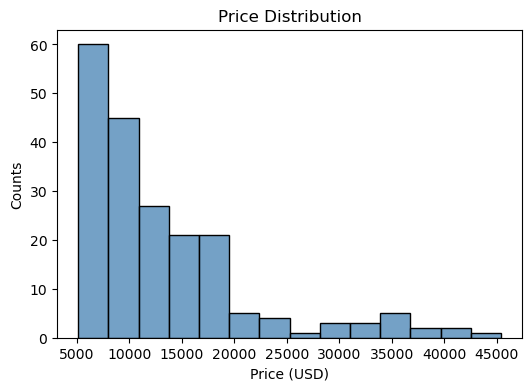

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Counts')
plt.show()

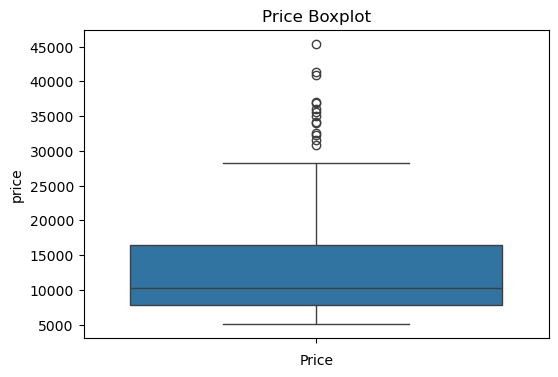

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(df['price'])
plt.title('Price Boxplot')
plt.xlabel('Price')
plt.show()

#### Univariate Analysis for Numerical Features

### Univariate — Numerical Features

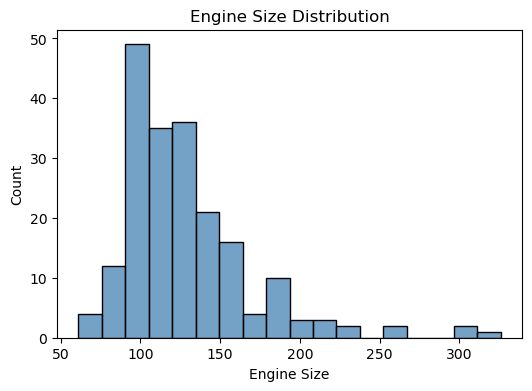

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(df['engine_size'], color='steelblue')
plt.title('Engine Size Distribution')
plt.xlabel('Engine Size')
plt.ylabel('Count')
plt.show()


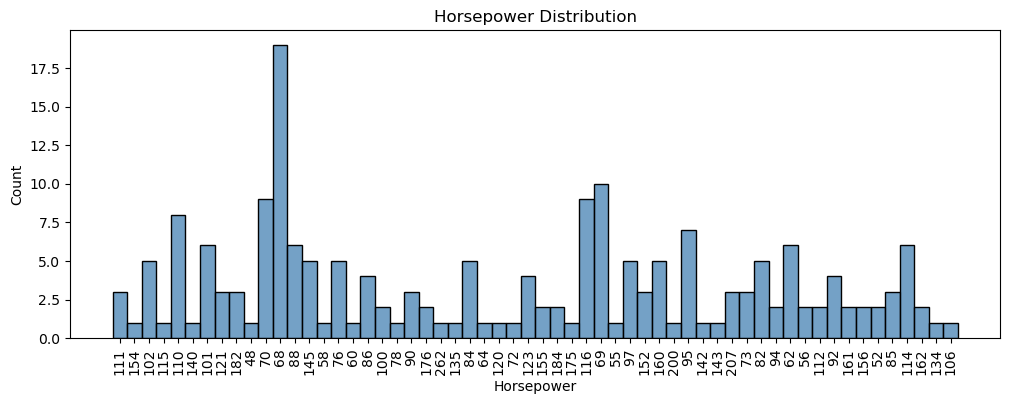

In [24]:
plt.figure(figsize=(12, 4))
sns.histplot(df['horsepower'], bins=20, color='steelblue')
plt.title('Horsepower Distribution')
plt.xlabel('Horsepower')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

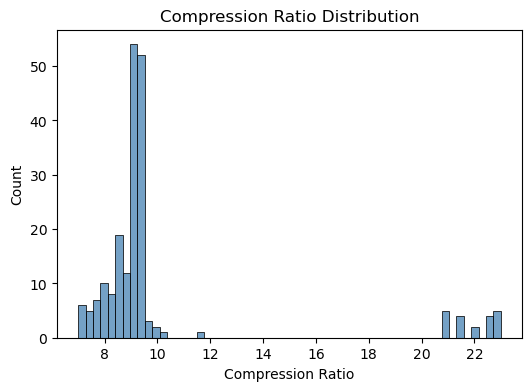

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(df['compression_ratio'], color='steelblue')
plt.title('Compression Ratio Distribution')
plt.xlabel('Compression Ratio')
plt.ylabel('Count')
plt.show()

#### Univariate Analysis for Categorical Data

### Univariate — Categorical Features

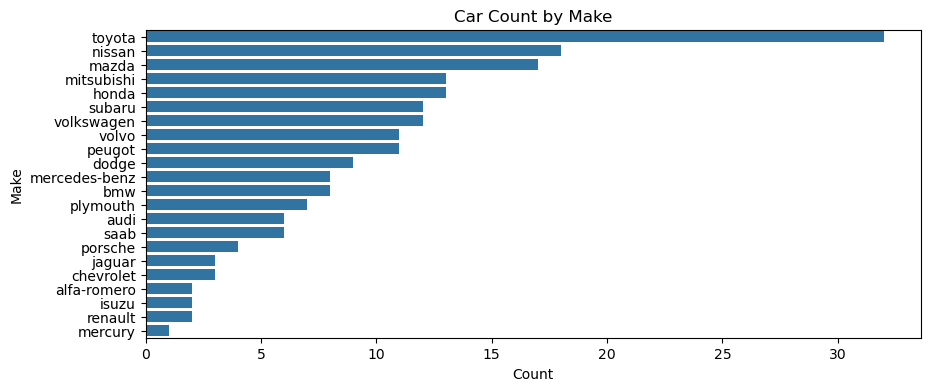

In [26]:
plt.figure(figsize=(10, 4))
sns.countplot(y=df['make'], order=df['make'].value_counts().index)
plt.title('Car Count by Make')
plt.xlabel('Count')
plt.ylabel('Make')
plt.show()

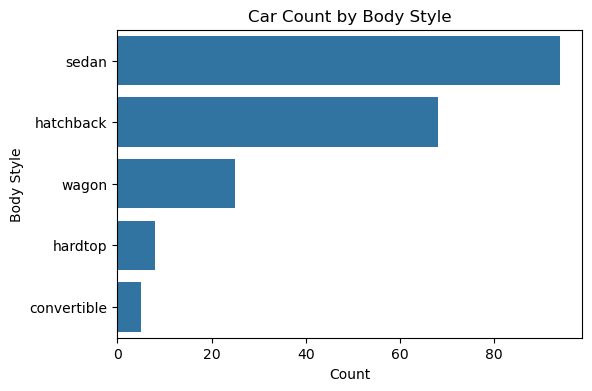

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(y=df['body_style'], order=df['body_style'].value_counts().index)
plt.title('Car Count by Body Style')
plt.xlabel('Count')
plt.ylabel('Body Style')
plt.show()

#### Bivariate Analysis for Numerical Features

### Bivariate — Numerical vs Price
seeing how each feature relates to price

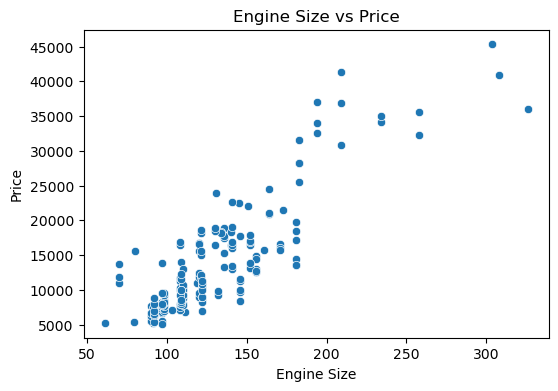

In [28]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['engine_size'], y=df['price'])
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()


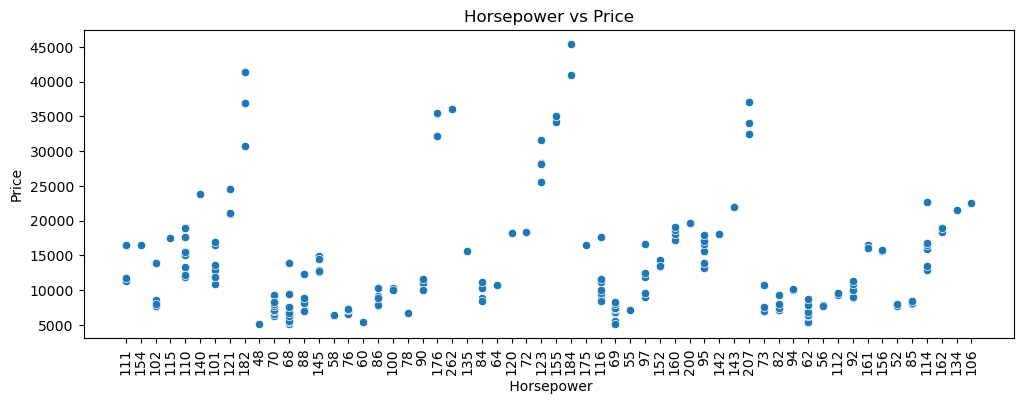

In [29]:
plt.figure(figsize=(12, 4))
sns.scatterplot(x=df['horsepower'], y=df['price'])
plt.title('Horsepower vs Price')
plt.xlabel(' Horsepower')
plt.ylabel('Price')
plt.xticks(rotation=90)
plt.show()


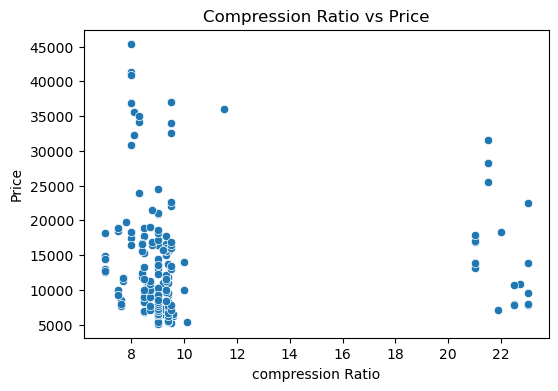

In [30]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df['compression_ratio'], y=df['price'])
plt.title('Compression Ratio vs Price')
plt.xlabel('compression Ratio')
plt.ylabel('Price')
plt.show()


#### Bivariate Analysis for Categorical Data

### Bivariate — Categorical vs Price

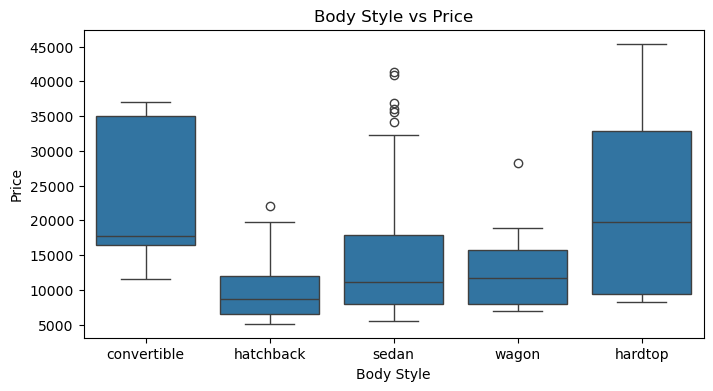

In [31]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['body_style'], y=df['price'])
plt.title('Body Style vs Price')
plt.xlabel('Body Style')
plt.ylabel('Price')
plt.show()

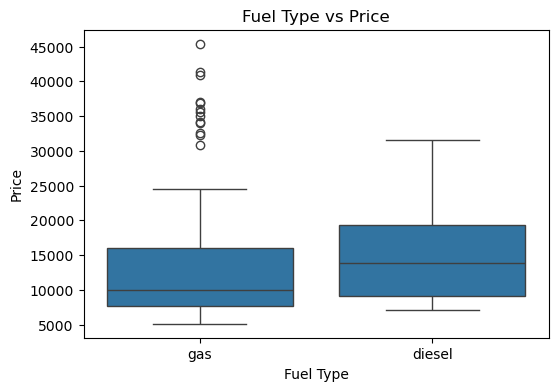

In [32]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['fuel_type'], y=df['price'])
plt.title('Fuel Type vs Price')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

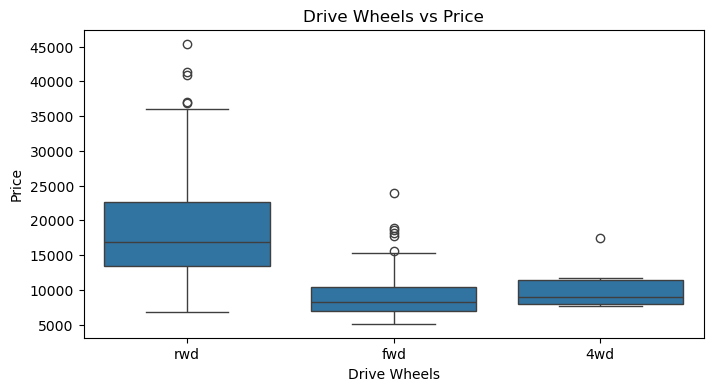

In [33]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['drive_wheels'], y=df['price'])
plt.title('Drive Wheels vs Price')
plt.xlabel('Drive Wheels')
plt.ylabel('Price')
plt.show()

#### Multivariate

### Multivariate Analysis

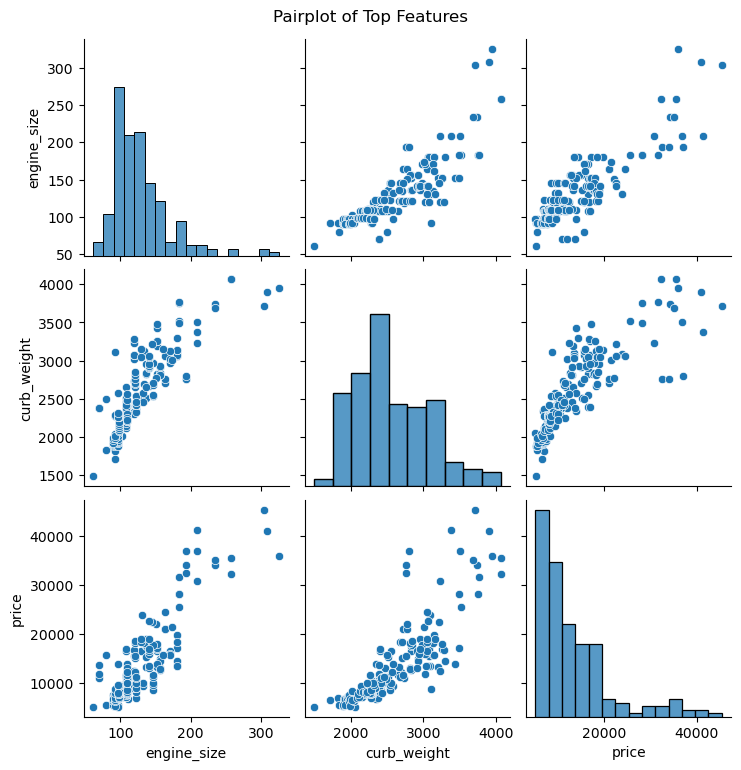

In [34]:
top_features = ['engine_size', 'horsepower', 'curb_weight', 'price']
sns.pairplot(df[top_features])
plt.suptitle('Pairplot of Top Features', y=1.02)
plt.show()

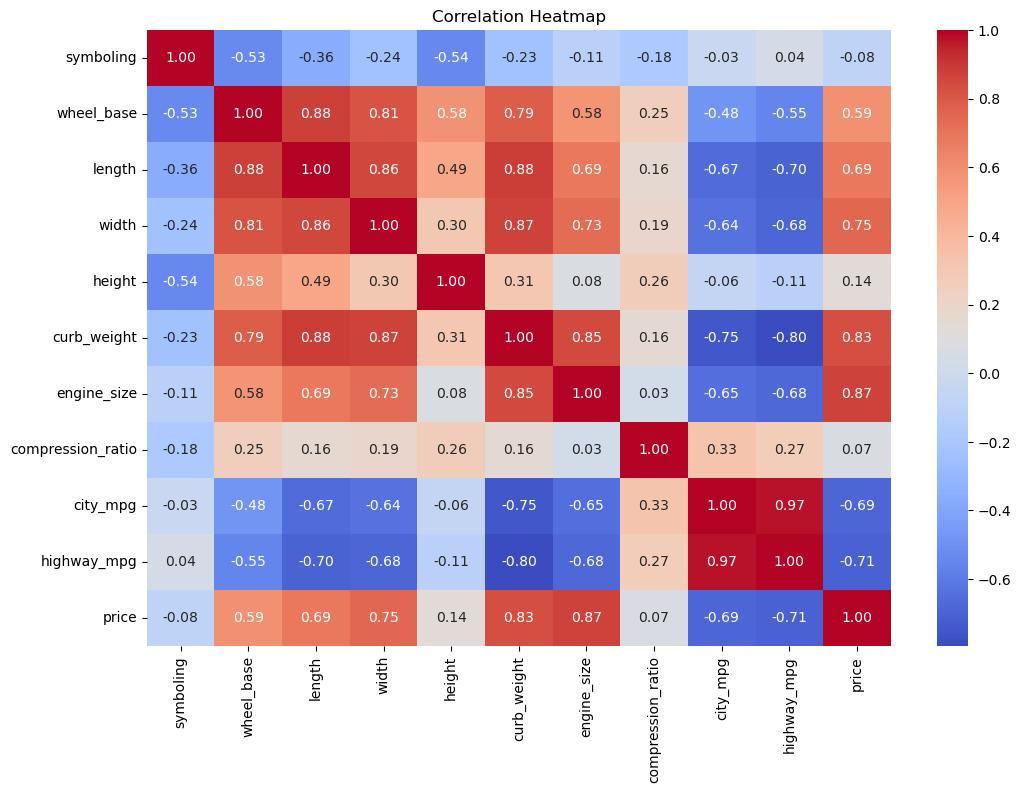

In [35]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Data Preprocessing and Feature Engineering

#### Missing Value Inputation

#### Data Type Fixing

separating numerical and categorical columns for different treatment

In [36]:
# Numerical columns (continuous + discrete)
num_cols = [
    'symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height',
    'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio',
    'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price'
]

# Categorical columns
cat_cols = [
    'make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style',
    'drive_wheels', 'engine_location', 'engine_type', 'fuel_system'
]

In [37]:
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

In [38]:
df[num_cols].dtypes

symboling              int64
normalized_losses    float64
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_size            int64
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                  int64
dtype: object

In [39]:
df[cat_cols] = df[cat_cols].astype('category')

In [40]:
df[cat_cols].dtypes

make               category
fuel_type          category
aspiration         category
num_of_doors       category
body_style         category
drive_wheels       category
engine_location    category
engine_type        category
fuel_system        category
dtype: object

In [41]:
df.isna().sum()

symboling             0
normalized_losses    36
make                  0
fuel_type             0
aspiration            0
num_of_doors          2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_of_cylinders      0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 0
dtype: int64

filling missing values — numerical with median, categorical with mode

In [42]:
num_cols=['horsepower','normalized_losses','bore','stroke','peak_rpm']
df[num_cols]=df[num_cols].apply(pd.to_numeric, errors='coerce')
df[num_cols]=df[num_cols].fillna(df[num_cols].median())
df['num_of_doors'].fillna(df['num_of_doors'].mode()[0], inplace=True)
print(df.isnull().sum())                                 

symboling            0
normalized_losses    0
make                 0
fuel_type            0
aspiration           0
num_of_doors         0
body_style           0
drive_wheels         0
engine_location      0
wheel_base           0
length               0
width                0
height               0
curb_weight          0
engine_type          0
num_of_cylinders     0
engine_size          0
fuel_system          0
bore                 0
stroke               0
compression_ratio    0
horsepower           0
peak_rpm             0
city_mpg             0
highway_mpg          0
price                0
dtype: int64


#### Feature Engineering

creating new features from existing ones — power to weight ratio and avg mpg

In [43]:
df['power_to_weight'] = df['horsepower'] / df['curb_weight']
df['avg_mpg'] = (df['city_mpg'] + df['highway_mpg']) / 2
df['engine_efficiency'] = df['horsepower'] / df['engine_size']
df['car_size'] = df['length'] * df['width'] * df['height']
print('Feature engineering done. Shape:', df.shape)

Feature engineering done. Shape: (200, 30)


#### Feature Encoding

In [44]:
df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price,power_to_weight,avg_mpg,engine_efficiency,car_size
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500,0.043564,24.0,0.853846,528019.904
1,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500,0.054552,22.5,1.013158,587592.640
2,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950,0.043646,27.0,0.935780,634816.956
3,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450,0.040722,20.0,0.845588,636734.832
4,2,115.0,audi,gas,std,two,sedan,fwd,front,99.8,...,8.5,110.0,5500.0,19,25,15250,0.043877,22.0,0.808824,624189.969


encoding text categories to numbers

In [45]:
print(df['num_of_cylinders'].unique())

['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']


In [46]:
df['num_of_cylinders']=df['num_of_cylinders'].map({'two':2, 'three':3, 'four':4, 'five':5, 'six':6,'eight':8, 'twelve':12})

In [47]:
print(df['num_of_doors'].unique())

['two', 'four']
Categories (2, object): ['four', 'two']


In [48]:
df['num_of_doors']=df['num_of_doors'].map({'two':2,'four':4})

In [49]:
threshold= 0.05 *len(df)
brand_counts=df['make'].value_counts()
top_brands=brand_counts[brand_counts >= threshold].index
print(threshold)
print(brand_counts)
print(top_brands)

10.0
make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
plymouth          7
audi              6
saab              6
porsche           4
jaguar            3
chevrolet         3
alfa-romero       2
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64
CategoricalIndex(['toyota', 'nissan', 'mazda', 'mitsubishi', 'honda', 'subaru',
                  'volkswagen', 'volvo', 'peugot'],
                 categories=['alfa-romero', 'audi', 'bmw', 'chevrolet', ..., 'subaru', 'toyota', 'volkswagen', 'volvo'], ordered=False, dtype='category', name='make')


In [50]:
df['make_top']=df['make'].apply(lambda x: x if x in top_brands else 'others')
df['make_top'].value_counts()

make_top
others        61
toyota        32
nissan        18
mazda         17
honda         13
mitsubishi    13
volkswagen    12
subaru        12
peugot        11
volvo         11
Name: count, dtype: int64

In [51]:
one_hot_cols = ['make_top','fuel_type', 'aspiration', 'body_style', 'drive_wheels',
            'engine_location', 'engine_type', 'fuel_system']

In [52]:
df=pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

In [53]:
df = df.drop(columns=['make'])

In [54]:
df

,symboling,normalized_losses,num_of_doors,wheel_base,length,width,height,curb_weight,num_of_cylinders,engine_size,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,3,115.0,2,88.6,168.8,64.1,48.8,2548,4,130,...,False,False,False,False,False,False,False,True,False,False
1,1,115.0,2,94.5,171.2,65.5,52.4,2823,6,152,...,False,True,False,False,False,False,False,True,False,False
2,2,164.0,4,99.8,176.6,66.2,54.3,2337,4,109,...,False,False,False,False,False,False,False,True,False,False
3,2,164.0,4,99.4,176.6,66.4,54.3,2824,5,136,...,False,False,False,False,False,False,False,True,False,False
4,2,115.0,2,99.8,177.3,66.3,53.1,2507,5,136,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1,95.0,4,109.1,188.8,68.9,55.5,2952,4,141,...,False,False,False,False,False,False,False,True,False,False
196,-1,95.0,4,109.1,188.8,68.8,55.5,3049,4,141,...,False,False,False,False,False,False,False,True,False,False
197,-1,95.0,4,109.1,188.8,68.9,55.5,3012,6,173,...,False,True,False,False,False,False,False,True,False,False
198,-1,95.0,4,109.1,188.8,68.9,55.5,3217,6,145,...,False,False,False,False,False,True,False,False,False,False


In [55]:
print(df.columns.tolist())

['symboling', 'normalized_losses', 'num_of_doors', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'num_of_cylinders', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price', 'power_to_weight', 'avg_mpg', 'engine_efficiency', 'car_size', 'make_top_mazda', 'make_top_mitsubishi', 'make_top_nissan', 'make_top_others', 'make_top_peugot', 'make_top_subaru', 'make_top_toyota', 'make_top_volkswagen', 'make_top_volvo', 'fuel_type_gas', 'aspiration_turbo', 'body_style_hardtop', 'body_style_hatchback', 'body_style_sedan', 'body_style_wagon', 'drive_wheels_fwd', 'drive_wheels_rwd', 'engine_location_rear', 'engine_type_l', 'engine_type_ohc', 'engine_type_ohcf', 'engine_type_ohcv', 'engine_type_rotor', 'fuel_system_2bbl', 'fuel_system_4bbl', 'fuel_system_idi', 'fuel_system_mfi', 'fuel_system_mpfi', 'fuel_system_spdi', 'fuel_system_spfi']


In [56]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

#### Log Transformation

price is right skewed — applying log transform to normalize it

In [57]:
df['log_price'] = np.log1p(df['price'])
print('Skewness after log transform:', round(df['log_price'].skew(), 3))

Skewness after log transform: 0.682


#### Train Test Split

## 5. Model Building

### Train Test Split
80/20 split — using log_price as target

In [58]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price', 'log_price'])
Y = df['log_price']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (160, 51)
Test set: (40, 51)


scaling features — important for linear models

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (160, 51)
X_test shape: (40, 51)


In [60]:
print(X_train[:2])


[[ 1.73618459 -0.19272097 -1.16316    -0.49295737 -0.05513283  0.2523344
  -1.49627136  0.78514236 -0.3386715   0.88508728  0.97743688  1.89477354
  -0.79979806  1.2331398  -0.31516714 -1.00098531 -1.02744399  1.15880577
  -1.02247193  0.58401344 -0.53450865 -0.30966177  4.35889894 -0.33333333
  -0.6352234  -0.25819889 -0.25819889 -0.42008403 -0.24413654 -0.27170849
   0.32163376  2.21944271 -0.19738551  1.4010578  -0.95118973 -0.388689
   0.83793058 -0.77459667 -0.11250879 -0.25819889  0.61588176 -0.2847474
  -0.24413654 -0.16012815 -0.67419986 -0.1382327  -0.32163376 -0.07930516
  -0.95118973  6.244998   -0.07930516]
 [-1.45679856 -0.80031419  0.85972695  1.77085206  1.25047944  1.59639472
   0.71540393  0.96989667  2.06965917  1.35611788  0.94070839 -1.21863029
  -0.33607234  0.91841734  0.72242016 -1.16178616 -1.18008191  0.56051417
  -1.18030648 -0.27123773  1.34666393 -0.30966177 -0.22941573 -0.33333333
  -0.6352234  -0.25819889 -0.25819889 -0.42008403 -0.24413654  3.680415
   0.

### Model 1 — Linear Regression (Baseline)

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [62]:
LR=LinearRegression()
LR.fit(X_train,Y_train)
Y_pred=LR.predict(X_test)

In [63]:
Y_pred

array([ 9.03404483, 10.42616782,  8.85489069,  9.02255902,  9.58499049,
        9.11937414, 10.90301631,  9.13082551,  9.8652392 , 11.7344217 ,
       10.36610959,  9.19069426,  9.31506223,  9.40546653,  9.5175986 ,
        9.1655867 ,  9.20143796,  8.86285549,  9.0475063 , 10.89808926,
       10.89277505,  7.88841127,  8.82115361,  8.82196391, 10.12348921,
        9.16210467,  9.27154654, 10.5622643 ,  9.28720524,  9.65798395,
        9.56987089,  8.73818885,  9.19300574,  9.03701336,  9.14796757,
        9.7023571 ,  8.88195351,  8.94823741,  9.36321241,  9.29859096])

In [64]:
r2=r2_score(Y_test,Y_pred) 
print('R2:',round(r2,4))

R2: 0.7907


In [65]:
rmse=np.sqrt(mean_squared_error(Y_test,Y_pred))
print('RMSE:',round(rmse,4))             

RMSE: 0.2703


In [66]:
mae=mean_absolute_error(Y_test,Y_pred)
print('MAE:',round(mae,4))                       

MAE: 0.165


In [67]:
from sklearn.model_selection import cross_val_score
CV_r2=cross_val_score(LR, X_train,Y_train, cv=5, scoring='r2')

print('CV R2 scores:',CV_r2.round(4))
print('Mean CV R2:', round(CV_r2.mean(),4))
print('STD CV R2:', round(CV_r2.std(),4))


CV R2 scores: [0.9101 0.8567 0.8553 0.8778 0.7993]
Mean CV R2: 0.8598
STD CV R2: 0.0362


### Model 2 — Ridge Regression
handles multicollinearity better than linear regression

In [68]:
from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(X_train,Y_train)
Y_pred_ridge= ridge.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2=r2_score(Y_test,Y_pred_ridge)
rmse=np.sqrt(mean_squared_error(Y_test,Y_pred_ridge))
mae=mean_absolute_error(Y_test,Y_pred_ridge)

print('R2:',round(r2,4))
print('RMSE:',round(rmse,4))
print('MAE:',round(mae,4))


R2: 0.8563
RMSE: 0.2239
MAE: 0.1479


In [69]:
CV_r2=cross_val_score(ridge, X_train,Y_train, cv=5, scoring='r2')
print('CV R2 scores:',CV_r2.round(4))
print('Mean CV R2:', round(CV_r2.mean(),4))
print('STD CV R2:', round(CV_r2.std(),4))

CV R2 scores: [0.911  0.8477 0.8677 0.8875 0.8689]
Mean CV R2: 0.8766
STD CV R2: 0.0214


### Model 3 — Decision Tree

In [70]:
from sklearn.tree import DecisionTreeRegressor
DTR=DecisionTreeRegressor(random_state=42)
DTR.fit(X_train,Y_train)
Y_pred_dt=DTR.predict(X_test)

r2=r2_score(Y_test,Y_pred_dt)
rmse=np.sqrt(mean_squared_error(Y_test,Y_pred_dt))
mae=mean_absolute_error(Y_test,Y_pred_dt)

print('R2:',round(r2,4))
print('RMSE:',round(rmse,4))
print('MAE:',round(mae,4))


R2: 0.9073
RMSE: 0.1798
MAE: 0.1189


In [71]:
CV_r2=cross_val_score(DTR, X_train,Y_train, cv=5, scoring='r2')
print('CV R2 scores:',CV_r2.round(4))
print('Mean CV R2:', round(CV_r2.mean(),4))
print('STD CV R2:', round(CV_r2.std(),4))

CV R2 scores: [0.879  0.8072 0.8674 0.8288 0.8595]
Mean CV R2: 0.8484
STD CV R2: 0.0265


### Model 4 — Random Forest

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, Y_train)
Y_pred_rf = rf.predict(X_test)

r2 = r2_score(Y_test, Y_pred_rf)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_rf))
mae = mean_absolute_error(Y_test, Y_pred_rf)
cv_r2 = cross_val_score(rf, X_train, Y_train, cv=5, scoring='r2')

print('Random Forest Results:')
print('R2  :', round(r2, 4))
print('RMSE:', round(rmse, 4))
print('MAE :', round(mae, 4))
print('CV R2:', round(cv_r2.mean(), 4))
print('Std  :', round(cv_r2.std(), 4))

Random Forest Results:
R2  : 0.9423
RMSE: 0.142
MAE : 0.1056
CV R2: 0.8995
Std  : 0.0134


### Model 5 — Gradient Boosting

In [73]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, Y_train)
Y_pred_gb = gb.predict(X_test)

r2 = r2_score(Y_test, Y_pred_gb)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_gb))
mae = mean_absolute_error(Y_test, Y_pred_gb)
cv_r2 = cross_val_score(gb, X_train, Y_train, cv=5, scoring='r2')

print('Gradient Boosting Results:')
print('R2  :', round(r2, 4))
print('RMSE:', round(rmse, 4))
print('MAE :', round(mae, 4))
print('CV R2:', round(cv_r2.mean(), 4))
print('Std  :', round(cv_r2.std(), 4))

Gradient Boosting Results:
R2  : 0.9431
RMSE: 0.1409
MAE : 0.1123
CV R2: 0.8935
Std  : 0.0224


In [74]:
models_dict = {
    'Linear Regression': LR,
    'Ridge': ridge,
    'Decision Tree': DTR,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

## 6. Model Evaluation

comparing all models on train R2 and CV R2

In [75]:
for name, model in models_dict.items():
    train_r2 = r2_score(Y_train, model.predict(X_train))
    test_r2 = r2_score(Y_test, model.predict(X_test))
    gap = train_r2 - test_r2
    print(name, '| Train R2:', round(train_r2, 4), '| Test R2:', round(test_r2, 4), '| Gap:', round(gap, 4))

Linear Regression | Train R2: 0.9501 | Test R2: 0.7907 | Gap: 0.1594
Ridge | Train R2: 0.9476 | Test R2: 0.8563 | Gap: 0.0914
Decision Tree | Train R2: 0.9996 | Test R2: 0.9073 | Gap: 0.0923
Random Forest | Train R2: 0.9866 | Test R2: 0.9423 | Gap: 0.0444
Gradient Boosting | Train R2: 0.9924 | Test R2: 0.9431 | Gap: 0.0493


### Hyperparameter Tuning

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, Y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV R2     :', round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2     : 0.9005


In [77]:
best_rf = grid_search.best_estimator_

Y_pred_best = best_rf.predict(X_test)

r2 = r2_score(Y_test, Y_pred_best)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_best))
mae = mean_absolute_error(Y_test, Y_pred_best)

print('Tuned Random Forest Results:')
print('R2  :', round(r2, 4))
print('RMSE:', round(rmse, 4))
print('MAE :', round(mae, 4))

Tuned Random Forest Results:
R2  : 0.9397
RMSE: 0.145
MAE : 0.1066


### Feature Importance — Random Forest
which features matter most for price prediction?

In [78]:
feature_names = df.drop(columns=['price', 'log_price']).columns

importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)


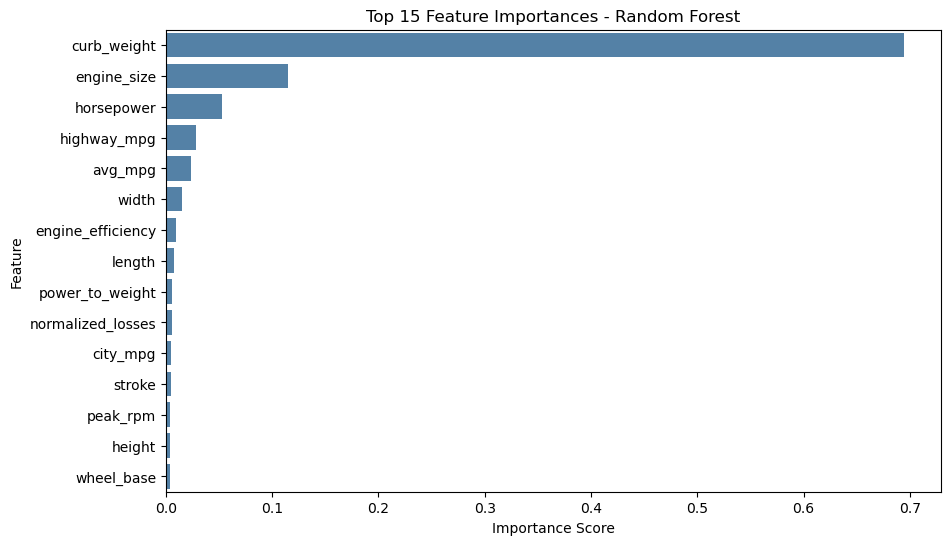

In [79]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp[:15].values, y=feat_imp[:15].index, color='steelblue')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

### Model Comparision 

## 7. Model Comparison Report

In [80]:
results = {
    'Model': ['Linear Regression', 'Ridge', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Tuned Random Forest'],
    'Test R2': [0.7907, 0.8563, 0.9073, 0.9423, 0.9431, 0.9397],
    'CV R2': [0.8598, 0.8766, 0.8484, 0.8995, 0.8935, 0.9005],
    'RMSE': [0.2703, 0.2239, 0.1798, 0.1420, 0.1409, 0.1450],
    'MAE': [0.1650, 0.1650, 0.1189, 0.1056, 0.1123, 0.1066]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


              Model  Test R2  CV R2   RMSE    MAE
  Linear Regression   0.7907 0.8598 0.2703 0.1650
              Ridge   0.8563 0.8766 0.2239 0.1650
      Decision Tree   0.9073 0.8484 0.1798 0.1189
      Random Forest   0.9423 0.8995 0.1420 0.1056
  Gradient Boosting   0.9431 0.8935 0.1409 0.1123
Tuned Random Forest   0.9397 0.9005 0.1450 0.1066


### Bar Chart

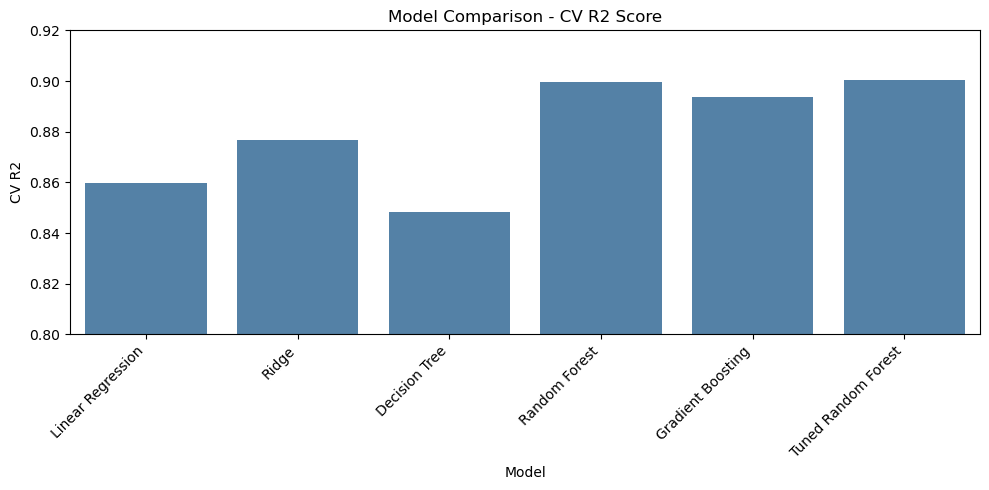

In [81]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='CV R2', data=results_df, color='steelblue')
plt.title('Model Comparison - CV R2 Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 0.92)
plt.tight_layout()
plt.show()


## Challenges and Solutions

### 1. Missing Values
**Challenge:** Several columns had missing values — normalized_losses(36), bore(4), 
stroke(4), horsepower(2), peak_rpm(2), num_of_doors(2).
**Solution:** Numerical columns filled with median to avoid influence of outliers. 
Categorical column num_of_doors filled with mode.

### 2. Skewed Target Variable
**Challenge:** Price had high skewness of 1.80 making it difficult for linear models.
**Solution:** Applied log transformation using np.log1p() reducing skewness to 0.682.

### 3. Outliers
**Challenge:** price(14), engine_size(10), compression_ratio(27) had significant outliers.
**Solution:** Applied IQR capping instead of removal to preserve all 200 rows.

### 4. High Cardinality in Make Column
**Challenge:** Make column had 22 unique brands making one hot encoding expensive.
**Solution:** Grouped brands with less than 5% frequency into 'other' category, 
reducing to 10 categories before encoding.

### 5. Multicollinearity
**Challenge:** Highly correlated features like city_mpg and highway_mpg, 
engine_size and horsepower inflated Linear Regression coefficients.
**Solution:** Applied Ridge Regression which penalizes large coefficients.

### 6. Small Dataset
**Challenge:** Only 200 rows making single train test split unreliable.
**Solution:** Applied 5 fold cross validation for reliable model evaluation.

### 7. Overfitting in Decision Tree
**Challenge:** Decision Tree achieved Train R2 of 0.9996 but CV R2 of only 0.8484.
**Solution:** Switched to Random Forest which averages multiple trees to reduce overfitting.